## Pre-requisites
1. Download the traces recorded from the experiments before running this notebook
2. Command to download the traces. `modal volume get duet-volume ./traces /traces`

In [39]:
# General Imports.
import json
import glob
import gzip
import re
import pandas as pd
from pathlib import Path
from collections import defaultdict


import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [29]:
# Setting up Constants

In [30]:
MODEL_NAME: str = "Qwen/Qwen2.5-Math-1.5B"
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

In [40]:
# Trace json containing the rollout data from Pytorch Profile
#TRACE_NAME: str = "rank0.1783097036625721759.pt.trace.json.gz"
TRACE_NAME: str = "rank0.1783099527726347115.pt.trace.json.gz"
ROLLOUT_TRACE_PATH: Path = Path(f"../traces/agent_loop_rollout_replica_0/{TRACE_NAME}")
# Experiment data saved during the verl-grpo experiments
DB_PATH = Path("../traces/duet-data/duet.db") 
# Rollout duration for each prompt's rollout during the generation phase.
TIMING_DIR: Path = Path("../traces/gen_times/")
PER_PROMPT_DATA = Path("../traces/rollout_data/2.jsonl")


In [46]:
## Core functions to record
# 1. Wall clock span of rollout
# 2. Bubble Ratio during rollout
# 3. Slowest 10%
# 4. Per-prompt length
# 5. Per-prompt reward


def load_traces(path: Path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as f:
        data = json.load(f)
    events = data.get("traceEvents", data) if isinstance(data, dict) else data
    return [e for e in events if e.get("ph") == "X" and "dur" in e]

def wall_clock_span(events):
    start_time = min(e["ts"] for e in events)
    end_time = max(e["ts"] + e["dur"] for e in events)
    return end_time - start_time


def bubble_ratio_sweep(durations):
    """Σ(Q - rk)·Δtk / (T·Q), with every request starting at t=0."""
    Q = len(durations)
    T = durations.max()

    # events: at t=0 all Q start (+Q); each request ends at its duration (-1)
    end_times = np.sort(durations)   # ascending end times

    bubble_sum = 0.0
    rk = Q                            # all running at t=0
    prev_t = 0.0
    for end_t in end_times:
        dt = end_t - prev_t
        bubble_sum += (Q - rk) * dt   # idle slots × interval width
        rk -= 1                       # this request finishes
        prev_t = end_t

    return bubble_sum / (Q * T)


def slowest_ten_percent(durations):
    durations_sorted = np.sort(durations)
    n_p10 = len(durations) // 10
    p10 = durations_sorted[-n_p10:]

    return f"{p10.sum()/arr.sum()*100:.1f}"

def get_per_prompt_length_and_reward(rollout_df):
    rollout_df["resp_len"] = rollout_df["output"].apply(lambda s: len(TOKENIZER(s)["input_ids"]))
    return rollout_df[["gts", "output", "resp_len", "score"]]
    

def plot_per_prompt_generation_time(durations):
    plt.hist(durations, bins=40, edgecolor="white")
    plt.xlabel("Per-prompt generation time (s)")
    plt.ylabel("Number of prompts")
    plt.title("Per-prompt generation time — training step 1")
    plt.show()


## Calculate & Display Metrics

In [26]:
# Compute the rollout wall-clock span
rollout_events = load_traces(ROLLOUT_TRACE_PATH)
rollout_wall_clock_span_us = wall_clock_span(rollout_events)
rollout_wall_clock_span_s = rollout_wall_clock_span_us / (1000 * 1000)
print(f"Rollout wall-clock span: {rollout_wall_clock_span_s:.2f}s.")

Rollout wall-clock span: 83.01s.


In [33]:
durations = np.load(TIMING_DIR / "gen_time_call002.npy")

In [34]:
# Compute the bubble ratio for the rollout.
print(f"Bubble ratio: {bubble_ratio_sweep(arr):.3f}  ({bubble_ratio_sweep(arr)*100:.1f}%)")

Bubble ratio: 0.459  (45.9%)


In [38]:
# Slowest 10%
slowest_ten = slowest_ten_percent(durations)
print(f"Slowest_10%:  {slowest_ten} %")

Slowest_10%:  17.6 %


In [44]:
## Load rollout jsonl as a dataframe
rollout_df = pd.read_json(PER_PROMPT_DATA, lines=True)
# print(rollout_df.columns.tolist())
# print(len(rollout_df), "rows")
# rollout_df[["gts", "score"]].head(100)

In [50]:
# Fetch the per-prompt length and reward.
result_df = get_per_prompt_length_and_reward(rollout_df)
result_df.head(10) 

,gts,output,resp_len,score
0,168,Write a number :\n\n\n([]*🤑,7,0
1,60,100,3,0
2,71,Please break down the problem as shown! '],9,0
3,9,####,1,0
4,20,Alyssa ate X nuggets.\n\n####,9,0
5,7,8\nThe total number of cats is 7. Please elabo...,29,0
6,33,$[answer],4,0
7,2,Show step by step reasoning here\n \n☕ faucet...,10,0
8,154,.$##Exercise: 7$\n####Exercise\n�####,12,0
9,95,intriguing problemcollection?\n }>,5,0


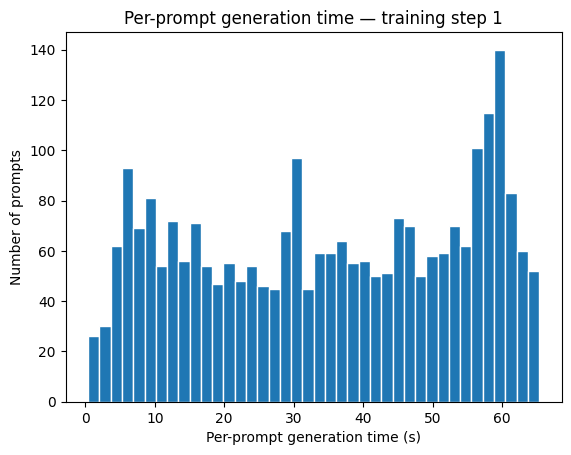

In [49]:
plot_per_prompt_generation_time(durations)